ElasticNet combines Ridge (L2) and Lasso (L1) penalties. Goal: see when ElasticNet beats plain Ridge/Lasso, using the classic diabetes dataset (10 correlated features).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

data = load_diabetes()
X, y = data.data, data.target
feature_names = data.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
print("Shape:", df.shape)
df.head()

Shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


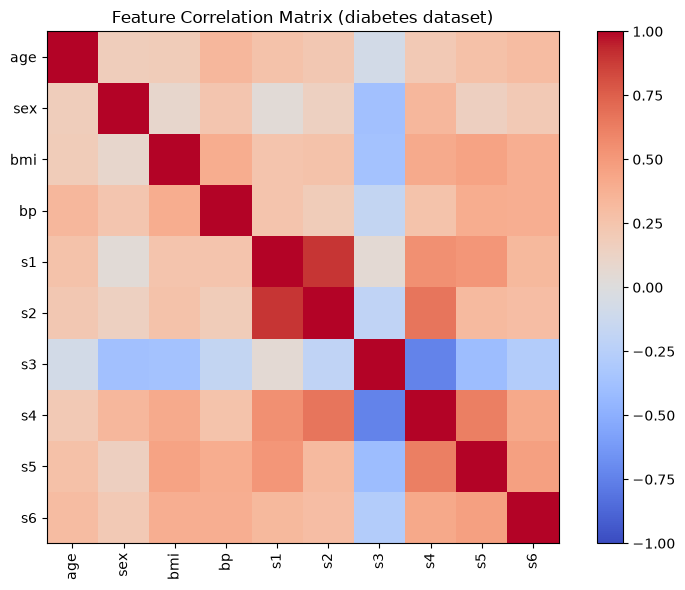

Highly correlated pairs (|corr| > 0.5):
  s1 <-> s2: 0.897
  s1 <-> s4: 0.542
  s1 <-> s5: 0.516
  s2 <-> s4: 0.660
  s3 <-> s4: -0.738
  s4 <-> s5: 0.618


In [2]:
# Feature correlation - this is WHY ElasticNet matters
corr = df[feature_names].corr()
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.yticks(range(len(feature_names)), feature_names)
plt.title('Feature Correlation Matrix (diabetes dataset)')
plt.tight_layout()
plt.show()

print("Highly correlated pairs (|corr| > 0.5):")
for i in range(len(feature_names)):
    for j in range(i+1, len(feature_names)):
        if abs(corr.iloc[i, j]) > 0.5:
            print(f"  {feature_names[i]} <-> {feature_names[j]}: {corr.iloc[i, j]:.3f}")

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (353, 10), Test: (89, 10)


In [4]:
models = {
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=0.1),
    'ElasticNet (L1+L2)': ElasticNet(alpha=0.1, l1_ratio=0.5),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    n_zero_coefs = np.sum(np.abs(model.coef_) < 1e-6)
    results.append({'model': name, 'rmse': rmse, 'r2': r2, 'zero_coefs': n_zero_coefs})

results_df = pd.DataFrame(results)
print(results_df)

                model       rmse        r2  zero_coefs
0          Ridge (L2)  53.777454  0.454147           0
1          Lasso (L1)  53.708698  0.455541           0
2  ElasticNet (L1+L2)  53.539343  0.458970           0


In [5]:
# Tune ElasticNet's two hyperparameters: alpha (overall strength) and l1_ratio (L1 vs L2 mix)
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1.0, 10.0],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
}

grid = GridSearchCV(ElasticNet(max_iter=10000), param_grid, cv=5, scoring='neg_mean_squared_error')
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"Tuned ElasticNet -> RMSE: {rmse:.2f}, R2: {r2:.4f}")

Best params: {'alpha': 0.1, 'l1_ratio': 0.1}
Tuned ElasticNet -> RMSE: 53.49, R2: 0.4600


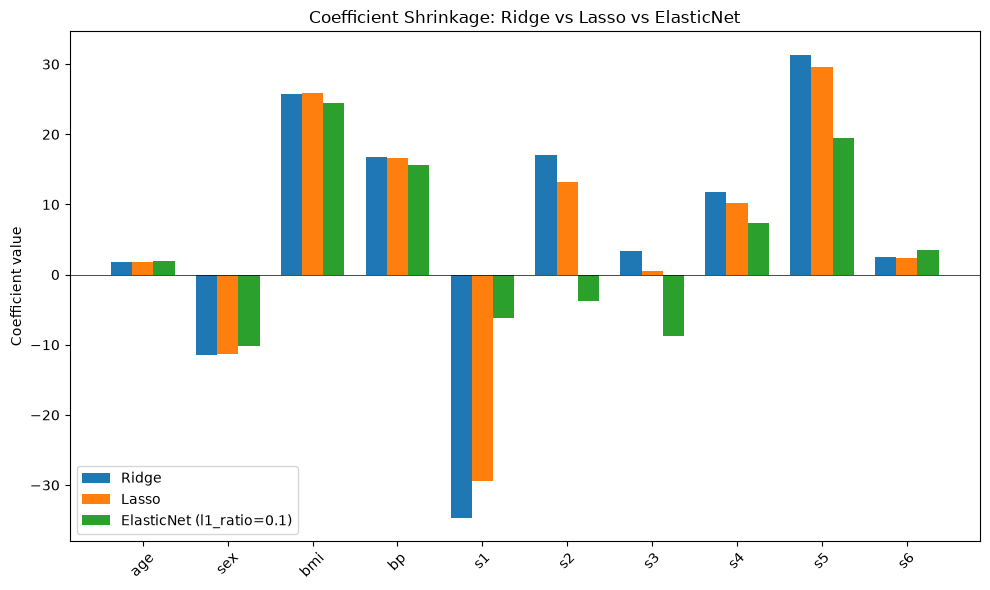

In [6]:
# Coefficient comparison - see how each model shrinks/zeroes weights differently
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(feature_names))
width = 0.25

ax.bar(x_pos - width, models['Ridge (L2)'].coef_, width, label='Ridge')
ax.bar(x_pos, models['Lasso (L1)'].coef_, width, label='Lasso')
ax.bar(x_pos + width, best_model.coef_, width, label=f'ElasticNet (l1_ratio={grid.best_params_["l1_ratio"]})')

ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names, rotation=45)
ax.set_ylabel('Coefficient value')
ax.set_title('Coefficient Shrinkage: Ridge vs Lasso vs ElasticNet')
ax.legend()
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

   l1_ratio       rmse  nonzero_coefs
0       0.0  53.478801             10
1       0.1  53.487835             10
2       0.3  53.510354             10
3       0.5  53.539343             10
4       0.7  53.578882              9
5       0.9  53.654722             10
6       1.0  53.708698             10


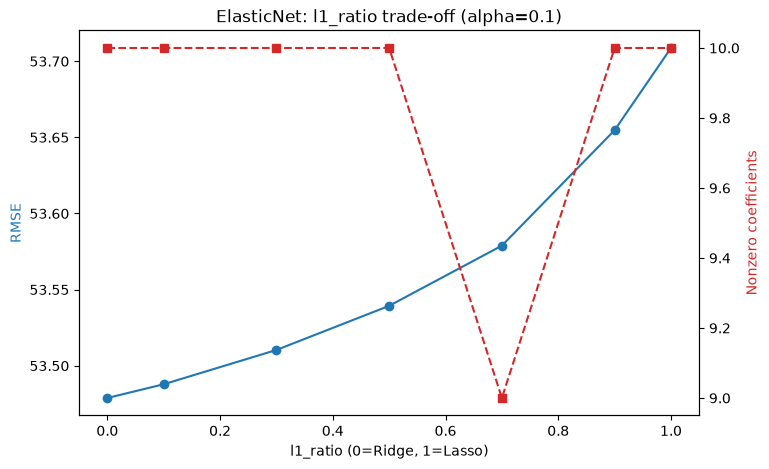

In [7]:
# l1_ratio sweep: 0 = pure Ridge, 1 = pure Lasso
l1_ratios = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0]
sweep = []
for l1r in l1_ratios:
    m = ElasticNet(alpha=0.1, l1_ratio=max(l1r, 1e-4), max_iter=10000)
    m.fit(X_train_scaled, y_train)
    pred = m.predict(X_test_scaled)
    sweep.append({'l1_ratio': l1r, 'rmse': np.sqrt(mean_squared_error(y_test, pred)),
                  'nonzero_coefs': np.sum(np.abs(m.coef_) > 1e-6)})

sweep_df = pd.DataFrame(sweep)
print(sweep_df)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(sweep_df['l1_ratio'], sweep_df['rmse'], 'o-', color='tab:blue', label='RMSE')
ax1.set_xlabel('l1_ratio (0=Ridge, 1=Lasso)')
ax1.set_ylabel('RMSE', color='tab:blue')
ax2 = ax1.twinx()
ax2.plot(sweep_df['l1_ratio'], sweep_df['nonzero_coefs'], 's--', color='tab:red', label='Nonzero coefs')
ax2.set_ylabel('Nonzero coefficients', color='tab:red')
plt.title('ElasticNet: l1_ratio trade-off (alpha=0.1)')
plt.show()